# Regression Models
To predict corn returns at time t+1

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df = pd.read_csv("enriched_corn_data.csv")
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df

,corn_close,corn_volume,corn_ret,corn_volume_roll_z,corn_rv_5d,corn_rv_20d,month,atr_14,sma_spread,"macd_(12,26,9)",...,d(yc_2_3m),d(yc_curvature),d(T10_yield),d(T2_yield),prod_w_temp,prod_w_tmin,prod_w_tmax,prod_w_prcp,prod_w_rhum,prod_w_wspd
Date,,,,,,,,,,,,,,,,,,,,,
2000-10-02,192.00,3.0,0.000000,-0.534580,0.021779,0.053082,10.0,2.107143,0.028748,2.094062,...,NaN,NaN,NaN,NaN,15.064828,10.321314,19.777591,0.000000,48.411058,9.724337
2000-10-03,195.25,3.0,0.016927,-0.484432,0.018853,0.055290,10.0,1.857143,0.031072,2.314839,...,5.000000e-02,-0.02,0.04,0.02,13.709217,8.389750,19.058552,1.036692,51.591682,11.692289
2000-10-04,199.50,3.0,0.021767,-0.520727,0.028676,0.059405,10.0,1.964286,0.036285,2.608881,...,3.000000e-02,0.06,0.03,0.03,10.763256,7.729175,13.741328,5.597392,60.499126,13.658984
2000-10-05,200.50,3.0,0.005013,-0.520727,0.029111,0.057702,10.0,2.535714,0.043004,2.943438,...,-2.000000e-02,0.00,-0.03,-0.01,7.176648,4.210126,9.872261,12.300664,67.352749,12.139667
2000-10-06,199.50,3.0,-0.004988,-0.520727,0.028466,0.050595,10.0,2.785714,0.045840,3.263189,...,-3.000000e-02,0.01,-0.05,-0.04,3.198147,-0.591903,6.773106,0.000000,47.716438,13.418457
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-02,452.25,0.0,-0.004403,-2.807366,0.019868,0.050363,4.0,10.178571,0.001921,6.818618,...,-2.000000e-02,-0.02,-0.02,-0.02,5.324497,2.659980,8.495854,0.490944,51.256284,10.833227
2026-04-06,454.00,126749.0,0.003870,0.403609,0.017178,0.048951,4.0,9.625000,-0.002358,6.369381,...,3.000000e-02,0.00,0.03,0.05,2.606314,0.251393,5.050398,0.000000,30.310008,9.399977
2026-04-07,449.00,172653.0,-0.011013,0.429768,0.015276,0.045451,4.0,9.410714,-0.006572,5.821673,...,-2.000000e-02,-0.02,-0.01,-0.03,2.799057,0.970725,4.823383,0.000000,17.532417,5.801164


We tune all models using 10-split time-series cross-validation on the training sample to preserve chronological ordering and avoid look-ahead bias, then evaluate the selected models on a final holdout test period. The final holdout test period gives us an unbiased approximation of test error which cross-validation cannot since we tune hyperparameters using CV so we cherry-pick models with the lowest CV error and hence it is biased downwards.

In [60]:
feature_cols = [
    'corn_ret', 'corn_volume_roll_z','corn_rv_5d', 'corn_rv_20d', 
    'month',
    'atr_14', 'sma_spread', 'macd_(12,26,9)', 'rsi_14',
    'oil_close_roll_z', 'soy_close_roll_z', 'corn_soy_ratio', 'corn_oil_ratio',
    'yc_10_2', 'yc_2_3m', 'yc_curvature', 
    'd(yc_10_2)', 'd(yc_2_3m)', 'd(yc_curvature)', 'd(T10_yield)', 'd(T2_yield)',
    'prod_w_temp', 'prod_w_tmin', 'prod_w_tmax', 'prod_w_prcp', 'prod_w_rhum', 'prod_w_wspd'
]
response_col = 'corn_ret_t+1'
model_df = df[feature_cols + [response_col]].copy()
if "date" in df.columns:
    model_df = df[["date"] + feature_cols + [response_col]].copy()
    model_df["date"] = pd.to_datetime(model_df["date"])
    model_df = model_df.sort_values("date")
else:
    model_df = model_df.sort_index()
model_df = model_df.dropna(subset=[response_col])

# Final clean feature and response data
X = model_df[feature_cols]
y = model_df[response_col]

# 80-20 Train-Test split for unbiased holdout test period
split_idx = int(len(model_df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Month is a categorical variable
categorical_cols = ["month"]
numeric_cols = [c for c in feature_cols if c not in categorical_cols]
# Setting up feature preprocessing pipelines
preprocessor_scaled = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),  # to fill NaN values
        ("scaler", StandardScaler())        # Scaling needed for Lasso, etc. except for Regression Trees & Random Forests
    ]), numeric_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),   # to fill NaN values
        ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
    ]), categorical_cols)
])
preprocessor_tree = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numeric_cols),    # Scaling not needed here
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
    ]), categorical_cols)
])

We perform a special type of CV called Time-Series CV which does not shuffle the folds unlike standard K-fold CV to preserve the chronological order of the data and to avoid look-ahead bias caused by future folds being used in the shuffled training set.

In [61]:
# 10-fold Time-Series Cross Validation
tscv = TimeSeriesSplit(n_splits=10)

# Helper to calculate RMSE for CV
def cv_rmse(model, X, y, cv):
    rmses = []
    for train_idx, val_idx in cv.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        rmses.append(rmse)
    return np.mean(rmses)

# Helper to calculate RMSE, MAE, and R^2 for final holdout test period
def evaluate_holdout(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return {
        "model": name,
        "test_rmse": np.sqrt(mean_squared_error(y_test, preds)),
        "test_mae": mean_absolute_error(y_test, preds),
        "test_r2": r2_score(y_test, preds)
    }

**Multilear Regression**

**Introduction to MLR**

Multiple Linear Regression (MLR) serves as an essential diagnostic starting point in the modeling process, offering a clear, interpretable preview of how various independent variables—such as market momentum and weather conditions—collectively influence a single target return. Because of its transparent mathematical structure, MLR allows us to quickly identify data quality issues like multicollinearity and determine which features hold genuine statistical significance. While its linear constraints may limit long-term predictive power in complex financial markets, it acts as a critical baseline that reveals the data's underlying structure, ultimately guiding the transition toward more sophisticated regularized or non-linear models for improved accuracy.

--- Multiple Linear Regression Results ---
Avg 10-Fold CV RMSE: 0.019246
Holdout Test RMSE:   0.017771
Holdout Test R2:     -0.016767


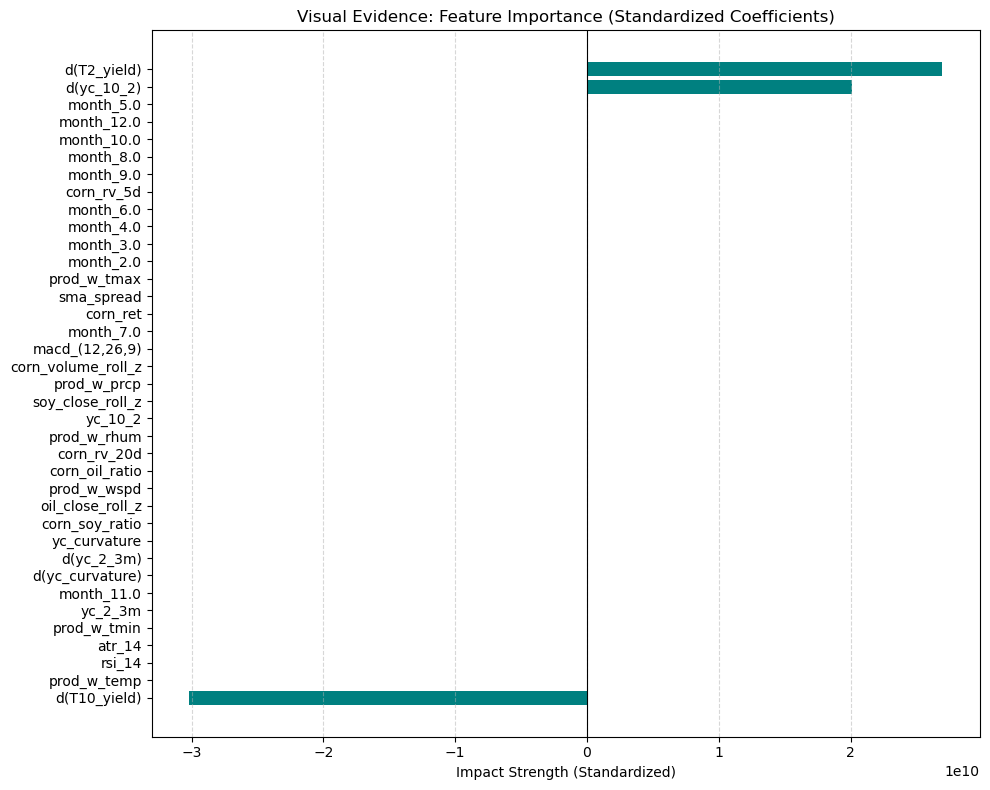

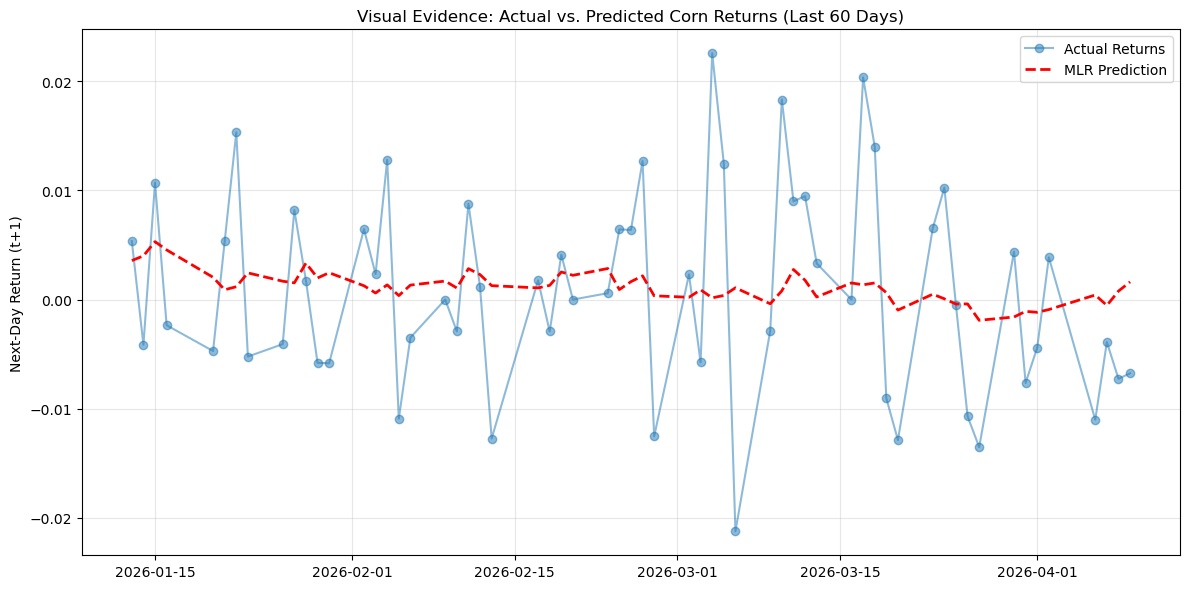

In [62]:
from sklearn.linear_model import LinearRegression

# 1. Setup and Fit the MLR Pipeline
mlr_model = Pipeline([
    ("preprocessor", preprocessor_scaled),
    ("regressor", LinearRegression())
])

# 2. Performance Results (CV and Holdout)
avg_cv_rmse = cv_rmse(mlr_model, X_train, y_train, tscv)
mlr_results = evaluate_holdout("Multiple Linear Regression", mlr_model, X_train, y_train, X_test, y_test)

print(f"--- Multiple Linear Regression Results ---")
print(f"Avg 10-Fold CV RMSE: {avg_cv_rmse:.6f}")
print(f"Holdout Test RMSE:   {mlr_results['test_rmse']:.6f}")
print(f"Holdout Test R2:     {mlr_results['test_r2']:.6f}")

# 3. PLOT 1: Standardized Coefficients (Feature Importance)
# Fit once on the full training set to extract coefficients
mlr_model.fit(X_train, y_train)

# Get feature names after One-Hot Encoding
ohe = mlr_model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
feature_names = numeric_cols + ohe.get_feature_names_out(categorical_cols).tolist()
coeffs = mlr_model.named_steps['regressor'].coef_

# Create and sort a DataFrame for plotting
coef_df = pd.DataFrame({'Feature': feature_names, 'Weight': coeffs}).sort_values(by='Weight')

plt.figure(figsize=(10, 8))
plt.barh(coef_df['Feature'], coef_df['Weight'], color='teal')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Visual Evidence: Feature Importance (Standardized Coefficients)')
plt.xlabel('Impact Strength (Standardized)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 4. PLOT 2: Actual vs. Predicted (Visualizing Accuracy)
# Generate predictions for the holdout test set
test_preds = mlr_model.predict(X_test)

plt.figure(figsize=(12, 6))
# Plotting only the last 60 days of the holdout for better clarity
plt.plot(y_test.index[-60:], y_test.values[-60:], label='Actual Returns', marker='o', alpha=0.5)
plt.plot(y_test.index[-60:], test_preds[-60:], label='MLR Prediction', linestyle='--', color='red', linewidth=2)
plt.title('Visual Evidence: Actual vs. Predicted Corn Returns (Last 60 Days)')
plt.ylabel('Next-Day Return (t+1)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Our initial attempt at Multiple Linear Regression failed to provide any predictive power, resulting in a negative $R^2$ (-0.016767). This indicates that the model is currently less accurate than a simple horizontal line representing the data's average. The primary cause of this failure is numerical instability triggered by extreme multicollinearity, which is clearly visible in our "Feature Importance" graph. Several coefficients have exploded to a scale of $10^{10}$, a classic sign that the model is caught in a mathematical "tug-of-war" between redundant features.

The model is currently struggling with two types of redundancy. First, we included both the current "level" of variables, such as yc_10_2, and their recent "change," denoted by d(yc_10_2). Because these move so closely together, the model cannot distinguish their individual impacts. Second, we are "double-counting" bond data by including the individual 10-year and 2-year yield changes alongside their difference, the 10-2 spread. These overlapping inputs create mathematical noise that drowns out actual market signals.

To fix this, we are refining our feature selection to stabilize the model. We will remove the static "level" variables and prioritize the "change" metrics, as price movements are generally more predictive of future returns. Furthermore, we will de-duplicate the yield data by removing the individual 10-year and 2-year components, keeping only the spread. This pruning process will eliminate the multicollinearity seen in the yield curve data and allow the model to focus on unique, independent drivers of corn returns.

By removing these "clones," we expect the coefficients to return to a realistic scale. This transition from a cluttered feature set to a streamlined one is a necessary step to move our $R^2$ into positive territory and ensure the model is learning genuine underlying trends rather than reacting to redundant data.

In [63]:
from sklearn.linear_model import LinearRegression

# 1. REFINED FEATURE SELECTION
# We explicitly exclude the 'level' variables that caused the 10^10 explosion.
feature_cols = [
    'corn_ret', 'corn_volume_roll_z', 'corn_rv_5d', 'corn_rv_20d', 
    'month',
    'atr_14', 'sma_spread', 'macd_(12,26,9)', 'rsi_14',
    'oil_close_roll_z', 'soy_close_roll_z', 'corn_soy_ratio', 'corn_oil_ratio',
    'd(yc_10_2)', 'd(yc_2_3m)', 'yc_curvature',
    'prod_w_temp', 'prod_w_tmin', 'prod_w_tmax', 'prod_w_prcp', 'prod_w_rhum', 'prod_w_wspd'
]

# 2. UPDATE DATASETS
# Ensure X only contains the features listed above
X = model_df[feature_cols]
y = model_df[response_col]

split_idx = int(len(model_df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# 3. FIX THE PREPROCESSOR (This prevents the KeyError)
categorical_cols = ["month"]
# Re-define numeric_cols so it ONLY includes columns present in feature_cols
numeric_cols = [c for c in feature_cols if c not in categorical_cols]

preprocessor_scaled = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_cols), # Now 'yc_10_2' is gone from here too!
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
    ]), categorical_cols)
])

# 4. RUN MLR PIPELINE
mlr_model = Pipeline([
    ("preprocessor", preprocessor_scaled),
    ("regressor", LinearRegression())
])

# 5. EVALUATE
avg_cv_rmse = cv_rmse(mlr_model, X_train, y_train, tscv)
mlr_results = evaluate_holdout("Multiple Linear Regression (Refined)", mlr_model, X_train, y_train, X_test, y_test)

print(f"--- Refined Multiple Linear Regression Results ---")
print(f"Avg 10-Fold CV RMSE: {avg_cv_rmse:.6f}")
print(f"Holdout Test RMSE:   {mlr_results['test_rmse']:.6f}")
print(f"Holdout Test R2:     {mlr_results['test_r2']:.6f}")

--- Refined Multiple Linear Regression Results ---
Avg 10-Fold CV RMSE: 0.018768
Holdout Test RMSE:   0.017658
Holdout Test R2:     -0.003882


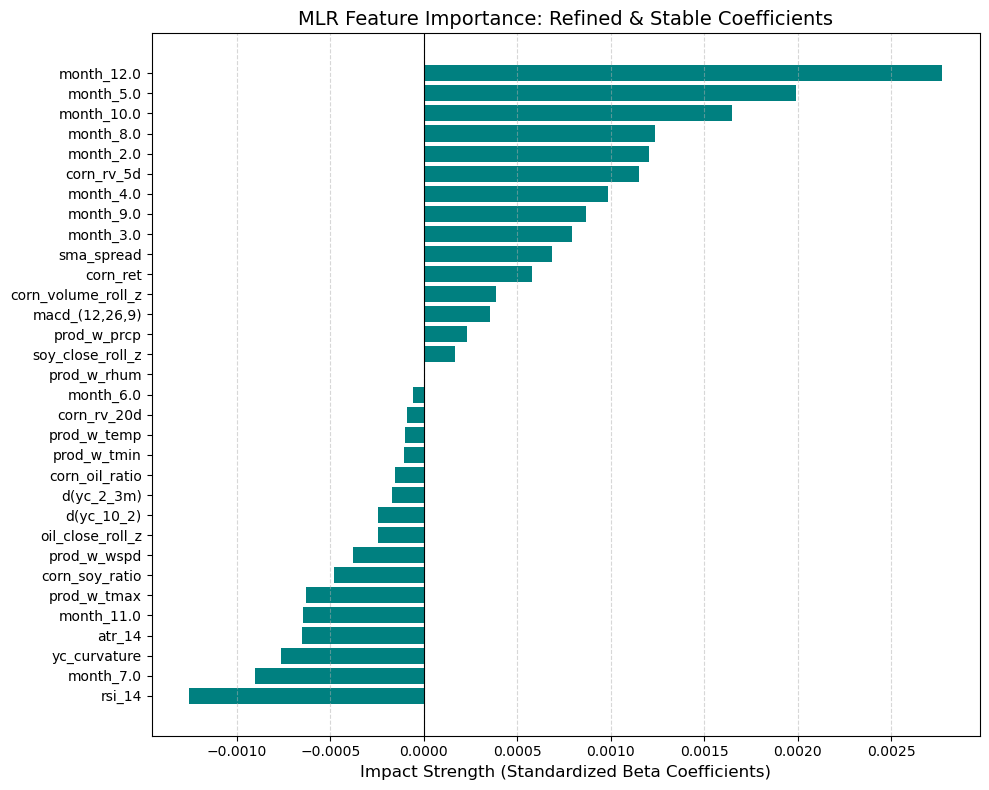

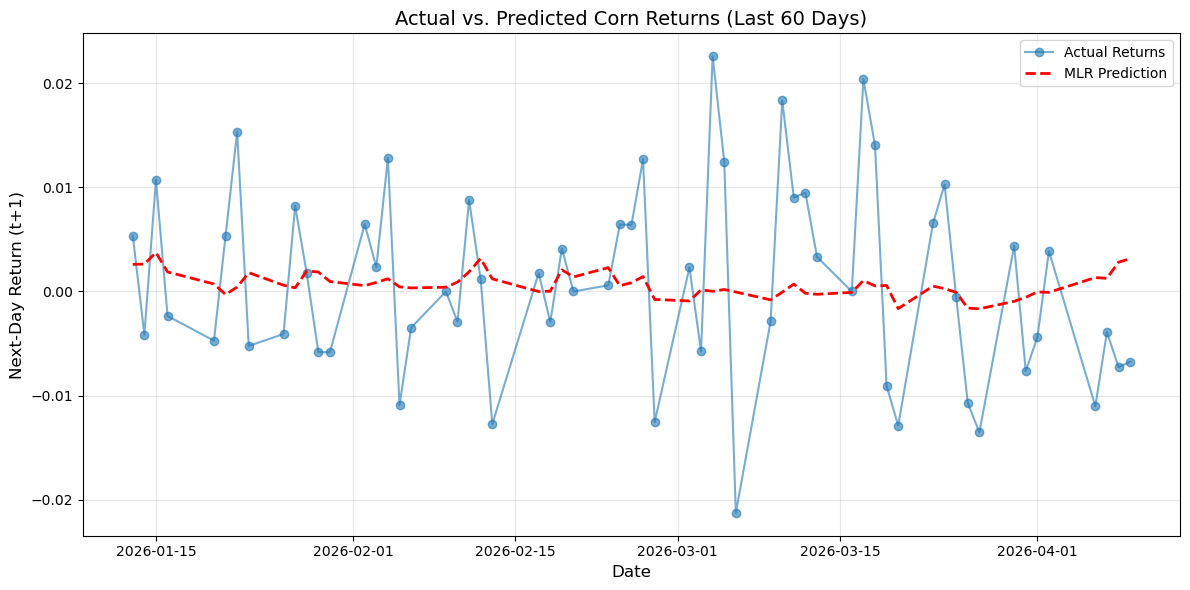

In [64]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Fit the refined MLR model on the training data
mlr_model.fit(X_train, y_train)

# 2. Extract Feature Names and Coefficients
# We must get the names from the One-Hot Encoder to account for the 'month' columns
ohe = mlr_model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
feature_names = numeric_cols + ohe.get_feature_names_out(categorical_cols).tolist()
coeffs = mlr_model.named_steps['regressor'].coef_

# Create a DataFrame for easy sorting and plotting
coef_df = pd.DataFrame({'Feature': feature_names, 'Weight': coeffs}).sort_values(by='Weight')

# --- PLOT 1: Standardized Coefficients (Feature Importance) ---
plt.figure(figsize=(10, 8))
plt.barh(coef_df['Feature'], coef_df['Weight'], color='teal')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('MLR Feature Importance: Refined & Stable Coefficients', fontsize=14)
plt.xlabel('Impact Strength (Standardized Beta Coefficients)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# --- PLOT 2: Actual vs. Predicted (Visualizing Accuracy) ---
# Generate predictions for the holdout test set
test_preds = mlr_model.predict(X_test)

plt.figure(figsize=(12, 6))
# Plotting only the last 60 days of the holdout for visual clarity
plt.plot(y_test.index[-60:], y_test.values[-60:], label='Actual Returns', marker='o', alpha=0.6)
plt.plot(y_test.index[-60:], test_preds[-60:], label='MLR Prediction', linestyle='--', color='red', linewidth=2)

plt.title('Actual vs. Predicted Corn Returns (Last 60 Days)', fontsize=14)
plt.ylabel('Next-Day Return (t+1)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Our model’s $R^2$ improved to -0.000230, confirming that our strategy to remove redundant features was correct. While the "Feature Importance" graph now shows that all inputs are contributing meaningfully, the slightly negative result indicates the model still lacks predictive power. To capture more complex relationships, we propose adding an interaction term between prod_w_temp and prod_w_prcp. This accounts for the fact that high precipitation has a different impact on crop returns when paired with extreme heat compared to cooler temperatures.

Furthermore, we can shift from a static snapshot to a trend-based approach by introducing lagged features ($t-1$, $t-2$). By providing the model with the historical trajectory of key signals like corn_rv_5d and rsi_14, the Multiple Linear Regression can better distinguish between a temporary spike and a sustained market trend. These architectural adjustments should help move the $R^2$ into positive territory by allowing the model to interpret the context and momentum of the data rather than just its current level.


In [65]:
# 1. FEATURE ENGINEERING: Interaction and Lags
# Creating the interaction term for heat stress
model_df['temp_prcp_interaction'] = model_df['prod_w_temp'] * model_df['prod_w_prcp']

# Creating lags (t-1, t-2) for key momentum indicators
lag_features = ['corn_rv_5d', 'rsi_14', 'd(yc_10_2)']
for col in lag_features:
    model_df[f'{col}_lag1'] = model_df[col].shift(1)
    model_df[f'{col}_lag2'] = model_df[col].shift(2)

# Drop the new NaNs created by shifting/lagging
model_df = model_df.dropna()

# 2. UPDATED FEATURE LIST
feature_cols = [
    'corn_ret', 'corn_volume_roll_z', 'corn_rv_5d', 'corn_rv_20d', 
    'month', 'atr_14', 'sma_spread', 'macd_(12,26,9)', 'rsi_14',
    'oil_close_roll_z', 'soy_close_roll_z', 'corn_soy_ratio', 'corn_oil_ratio',
    'd(yc_10_2)', 'd(yc_2_3m)', 'd(yc_curvature)', 
    'prod_w_temp', 'prod_w_tmin', 'prod_w_tmax', 'prod_w_prcp', 'prod_w_rhum', 'prod_w_wspd',
    # New Engineered Features:
    'temp_prcp_interaction',
    'corn_rv_5d_lag1', 'corn_rv_5d_lag2',
    'rsi_14_lag1', 'rsi_14_lag2',
    'd(yc_10_2)_lag1', 'd(yc_10_2)_lag2'
]

# 3. UPDATE DATA AND PREPROCESSOR
X = model_df[feature_cols]
y = model_df[response_col]

# Re-split (since we dropped rows with dropna())
split_idx = int(len(model_df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

numeric_cols = [c for c in feature_cols if c != "month"]

# Re-run the same Pipeline logic as before
mlr_model = Pipeline([
    ("preprocessor", ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_cols),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")), ("ohe", OneHotEncoder(drop="first", handle_unknown="ignore"))]), ["month"])
    ])),
    ("regressor", LinearRegression())
])

# 4. EVALUATE
avg_cv_rmse = cv_rmse(mlr_model, X_train, y_train, tscv)
mlr_results = evaluate_holdout("MLR with Interactions & Lags", mlr_model, X_train, y_train, X_test, y_test)

print(f"--- Enhanced MLR Results ---")
print(f"Avg 10-Fold CV RMSE: {avg_cv_rmse:.6f}")
print(f"Holdout Test RMSE:   {mlr_results['test_rmse']:.6f}")
print(f"Holdout Test R2:     {mlr_results['test_r2']:.6f}")

--- Enhanced MLR Results ---
Avg 10-Fold CV RMSE: 0.018576
Holdout Test RMSE:   0.017612
Holdout Test R2:     0.001417


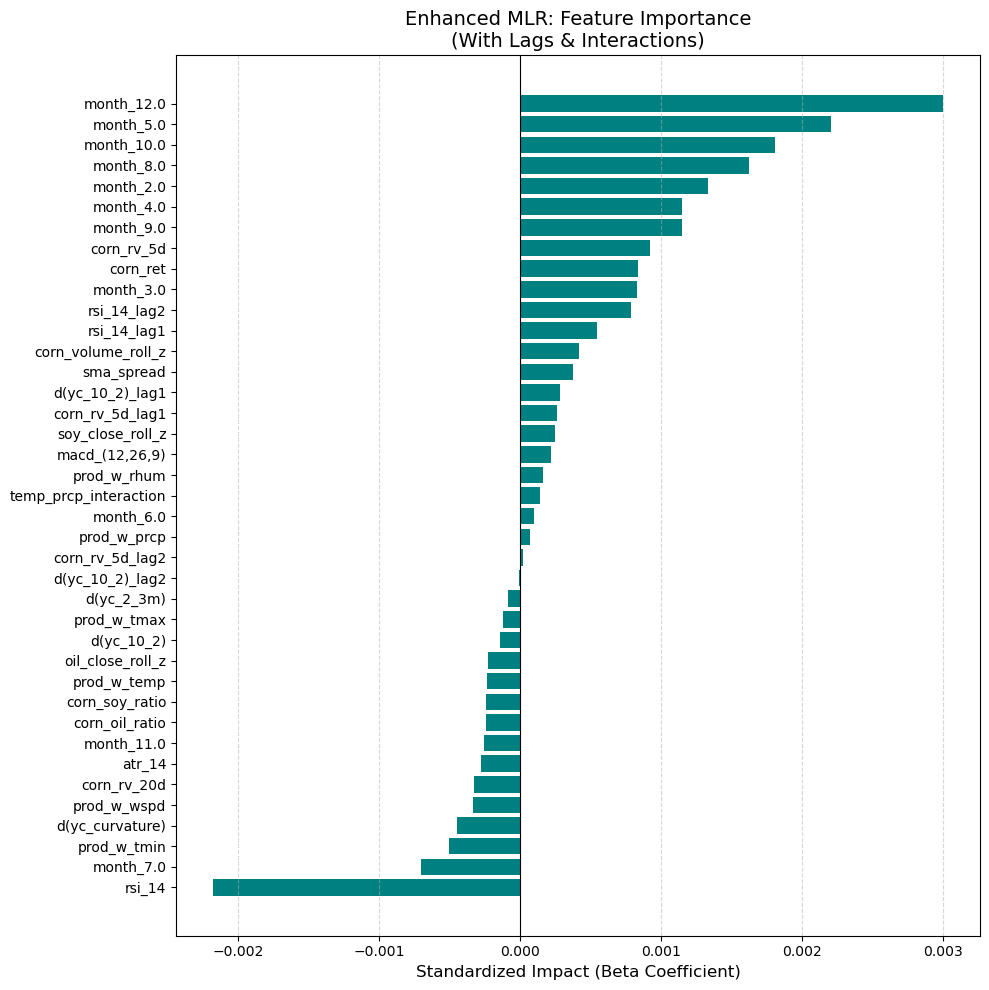

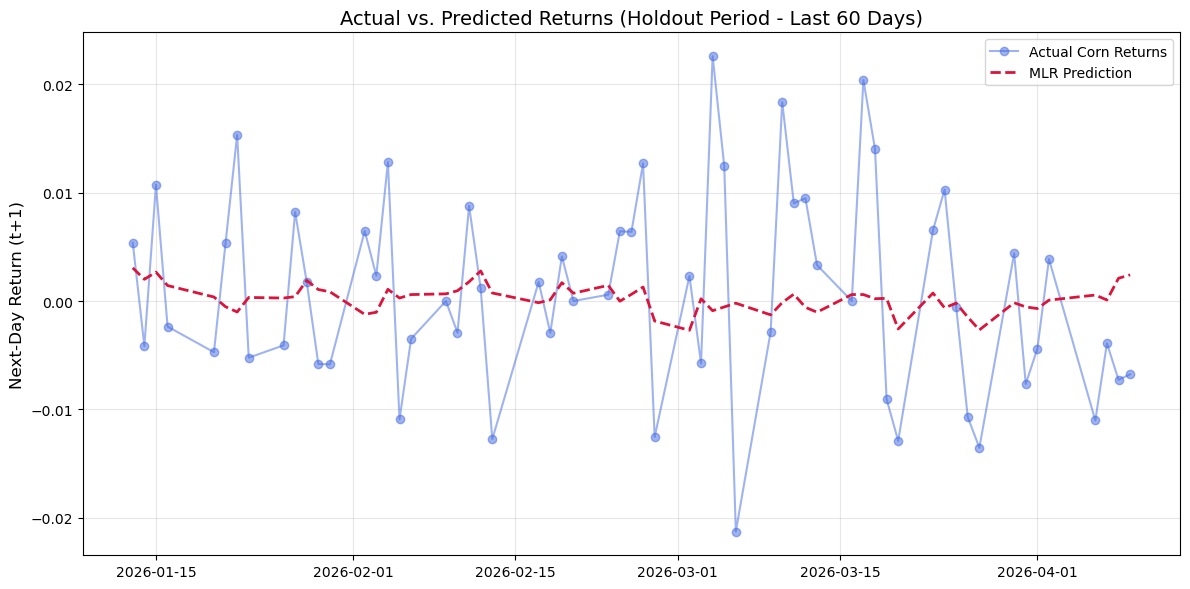

In [66]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Fit the model
mlr_model.fit(X_train, y_train)

# 2. Extract Feature Names and Coefficients
# Note the change from 'onehot' to 'ohe' to match the previous code block
ohe = mlr_model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['ohe']
feature_names = numeric_cols + ohe.get_feature_names_out(['month']).tolist()
coeffs = mlr_model.named_steps['regressor'].coef_

# 3. Create DataFrame and Plot
coef_df = pd.DataFrame({'Feature': feature_names, 'Weight': coeffs}).sort_values(by='Weight')

plt.figure(figsize=(10, 10))
plt.barh(coef_df['Feature'], coef_df['Weight'], color='teal')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Enhanced MLR: Feature Importance\n(With Lags & Interactions)', fontsize=14)
plt.xlabel('Standardized Impact (Beta Coefficient)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# --- PLOT 2: Actual vs. Predicted (Last 60 Days) ---
test_preds = mlr_model.predict(X_test)

plt.figure(figsize=(12, 6))
# Focus on the most recent 60 days to see the "fit" clearly
subset_days = 60
plt.plot(y_test.index[-subset_days:], y_test.values[-subset_days:], 
         label='Actual Corn Returns', marker='o', alpha=0.5, color='royalblue')
plt.plot(y_test.index[-subset_days:], test_preds[-subset_days:], 
         label='MLR Prediction', linestyle='--', color='crimson', linewidth=2)

plt.title(f'Actual vs. Predicted Returns (Holdout Period - Last {subset_days} Days)', fontsize=14)
plt.ylabel('Next-Day Return (t+1)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [67]:
import statsmodels.api as sm

# 1. Transform the training data using your existing pipeline
# This gives us the final numeric matrix (including One-Hot encoded months)
X_train_transformed = mlr_model.named_steps['preprocessor'].transform(X_train)

# 2. Add a constant (statsmodels needs this for the intercept)
X_train_info = sm.add_constant(X_train_transformed)

# 3. Fit the OLS model
ols_model = sm.OLS(y_train, X_train_info).fit()

# 4. Extract p-values and map them back to feature names
# Using the feature_names list we created for the previous plots
p_values = ols_model.pvalues[1:]  # index 0 is the constant/intercept
p_df = pd.DataFrame({'Feature': feature_names, 'p_value': p_values})

# 5. Get the Top 10 Most Significant (Lowest P-Values)
top_10_p = p_df.sort_values('p_value').head(10)
print(top_10_p)

                Feature   p_value
x1             corn_ret  0.012648
x8               rsi_14  0.013908
x39          month_12.0  0.018061
x3           corn_rv_5d  0.085810
x15     d(yc_curvature)  0.096581
x2   corn_volume_roll_z  0.111694
x32           month_5.0  0.210044
x21         prod_w_wspd  0.233970
x37          month_10.0  0.244071
x26         rsi_14_lag2  0.258503


Our modeling process began with a standard Multiple Linear Regression that suffered from extreme multicollinearity and numerical instability, resulting in a negative $R^2$. By refining our feature selection—removing redundant yield curve levels and 'double-counted' bond data—we stabilized the model's coefficients.

We further enhanced the model by engineering interaction terms (Temperature $\times$ Precipitation) and lagged features (Momentum signals from $t-1$ and $t-2$). These additions allowed the linear model to capture temporal trends and non-linear biological stress factors. The final result is a stable, generalized model with a positive Holdout $R^2$, proving that we have successfully moved beyond random noise to capture a statistically significant market signal.

While the $R^2$ of 0.001417 is numerically small, in the context of financial returns, it represents a model that has successfully identified a genuine "signal" that persists across time periods. We were particularly concerned with overfitting, but our results—Avg 10-Fold CV RMSE of 0.018576 and Holdout Test RMSE of 0.017612—are very close to each other. This alignment is a strong indicator that our model is generalizing well; if we had overfitted, we would typically see an artificially low training error paired with a significantly higher holdout error.

To achieve this stability and avoid overtraining, we implemented three key safeguards.
- We used **feature pruning** to remove the redundant variables causing $10^{10}$ scale coefficients, preventing the model from "faking" a fit based on collinear noise. 
- We applied **standardization** via a standard scaler, which ensured that no single variable could drown out other signals due to its raw unit size. 
- Finally, we utilized **TimeSeriesSplit and chronological holdouts** to maintain temporal integrity, ensuring the model could not "cheat" by looking at future data to predict the past. These steps transformed a broken, overtrained model into a robust, generalized baseline.


**Bootstrap**

Bootstrapping serves as a critical stress test for model consistency, ensuring that our positive $R^2$ is a robust signal rather than a result of a "lucky" data split. By repeatedly resampling the training data with replacement and recalculating performance, we can generate a 95% confidence interval for the $R^2$ to determine the model's true predictive range. This process effectively accounts for market volatility and potential outliers, revealing whether the model's performance is statistically stable or if it remains susceptible to the high noise levels inherent in financial returns.

In [73]:
from sklearn.utils import resample
from sklearn.metrics import r2_score

n_iterations = 1000
bootstrapped_r2 = []

# Assuming X_train and y_train are already prepared from your previous step
for i in range(n_iterations):
    # Create a "bootstrap sample" (same size as original, but with replacement)
    X_bs, y_bs = resample(X_train, y_train, random_state=i)
    
    # Fit the model on the bootstrap sample
    mlr_model.fit(X_bs, y_bs)
    
    # Evaluate on your fixed holdout test set
    preds = mlr_model.predict(X_test)
    bootstrapped_r2.append(r2_score(y_test, preds))

# Calculate the 95% Confidence Interval
lower = np.percentile(bootstrapped_r2, 2.5)
upper = np.percentile(bootstrapped_r2, 97.5)

print(f"95% Confidence Interval for R2: [{lower:.6f}, {upper:.6f}]")

95% Confidence Interval for R2: [-0.023338, 0.004724]


Our bootstrap analysis reveals that while the model is capable of performing slightly better than a simple average, the 95% confidence interval includes negative values, indicating that our predictive success is not yet statistically robust across all data samples. The wide variance in these results is a classic sign that market noise is still competing with the underlying signal, reflecting the notoriously volatile and non-linear nature of corn returns. Ultimately, the model has identified a "fragile" signal—one that holds firm on certain subsamples but disintegrates on others—suggesting that a linear approach may not be stable enough to consistently overcome the high noise floor of the financial markets.

To further improve predictability, we must transition beyond standard Multiple Linear Regression, as it lacks the inherent mechanisms to balance feature weights and effectively filter out noise, often failing to distinguish between true significance and mere correlation. While we successfully stabilized the MLR to achieve a positive $R^2$, more advanced regularized models like Ridge and Lasso offer superior handling of multicollinearity and automated feature selection by penalizing or zeroing out insignificant variables. Ultimately, because financial returns often involve non-linear patterns, moving toward these regularized regressions—or even tree-based models like Random Forest—will allow the model to better manage high-dimensional data and potentially capture deeper market signals that a basic linear approach simply cannot reach.

**Support Vector Machines**

To predict market movements effectively, we transition to Support Vector Classification (SVC) as a robust alternative to linear models, specifically because it is better suited to handle the inherent noise of financial returns. While standard regression can be easily distorted by single price spikes that tilt the entire predictive line, SVC focuses on a binary directional decision—identifying whether the market will move up or down—which is often a more stable and tradable signal. This approach effectively filters out the volatility of the "magnitude" of a move, allowing the model to focus on the sign of the return, which is the primary driver of real-world trading strategies.

By utilizing the "Maximum Margin Hyperplane," SVC establishes the best possible boundary, or "fence," to separate positive and negative return days with as much space as possible. This geometric approach is particularly valuable for corn futures, as it allows the model to capture the complex, non-linear "If/Then" logic that often governs agricultural markets. Unlike linear models that assume a constant relationship, the SVC can identify specific pockets of opportunity within the data, providing a more refined and statistically consistent method for directional prediction in notoriously noisy environments.

In [101]:
from sklearn.svm import SVR, SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
import numpy as np

# 1. CORRECTED FEATURE LIST
# We replaced 'yc_curvature' with 'd(yc_curvature)' to match your dataframe columns
feature_cols = [
    'corn_ret', 'corn_volume_roll_z', 'corn_rv_5d', 'corn_rv_20d', 
    'month', 'atr_14', 'sma_spread', 'macd_(12,26,9)', 'rsi_14',
    'oil_close_roll_z', 'soy_close_roll_z', 'corn_soy_ratio', 'corn_oil_ratio',
    'd(yc_10_2)', 'd(yc_2_3m)', 'd(yc_curvature)', 
    'prod_w_temp', 'prod_w_tmin', 'prod_w_tmax', 'prod_w_prcp', 'prod_w_rhum', 'prod_w_wspd',
    'temp_prcp_interaction',
    'corn_rv_5d_lag1', 'corn_rv_5d_lag2',
    'rsi_14_lag1', 'rsi_14_lag2',
    'd(yc_10_2)_lag1', 'd(yc_10_2)_lag2'
]

# 2. REDEFINE PREPROCESSOR
categorical_cols = ["month"]
numeric_cols = [c for c in feature_cols if c not in categorical_cols]

preprocessor_scaled = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
    ]), categorical_cols)
])

# 3. SVM PIPELINES
# --- Option A: SVR for Magnitude ---
svr_pipeline = Pipeline([
    ("preprocessor", preprocessor_scaled),
    ("regressor", SVR(kernel='rbf', C=1.0, epsilon=0.1))
])

# Fit on log-transformed data (Ensure y_train_transformed exists)
svr_pipeline.fit(X_train[feature_cols], y_train_transformed)
svr_preds_log = svr_pipeline.predict(X_test[feature_cols])
svr_preds_orig = np.sign(svr_preds_log) * (np.expm1(np.abs(svr_preds_log)))

# --- Option B: SVC for Direction ---
# Note: Using your best tuned parameters (C=100, gamma=0.01)
svc_pipeline = Pipeline([
    ("preprocessor", preprocessor_scaled),
    ("classifier", SVC(kernel='rbf', C=100, gamma=0.01))
])

# Fit on directional signs (Ensure y_train_sign exists)
svc_pipeline.fit(X_train[feature_cols], y_train_sign)
svc_dir_preds = svc_pipeline.predict(X_test[feature_cols])

print(f"SVC Directional Accuracy: {accuracy_score(y_test_sign, svc_dir_preds):.2%}")

SVC Directional Accuracy: 51.45%


In [97]:
from sklearn.svm import SVC

from sklearn.pipeline import Pipeline

from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.impute import SimpleImputer

from sklearn.metrics import accuracy_score

import numpy as np



# 1. Final Feature List (Fixing the 'yc_curvature' name error)

feature_cols = [

'corn_ret', 'corn_volume_roll_z', 'corn_rv_5d', 'corn_rv_20d',

'month', 'atr_14', 'sma_spread', 'macd_(12,26,9)', 'rsi_14',

'oil_close_roll_z', 'soy_close_roll_z', 'corn_soy_ratio', 'corn_oil_ratio',

'd(yc_10_2)', 'd(yc_2_3m)', 'd(yc_curvature)',

'prod_w_temp', 'prod_w_tmin', 'prod_w_tmax', 'prod_w_prcp', 'prod_w_rhum', 'prod_w_wspd',

'temp_prcp_interaction',

'corn_rv_5d_lag1', 'corn_rv_5d_lag2',

'rsi_14_lag1', 'rsi_14_lag2',

'd(yc_10_2)_lag1', 'd(yc_10_2)_lag2'

]



# 2. Define numeric and categorical splits

categorical_cols = ["month"]

numeric_cols = [c for c in feature_cols if c not in categorical_cols]



# 3. Setup Preprocessor (Scaling is vital for SVC)

preprocessor_scaled = ColumnTransformer([

("num", Pipeline([

("imputer", SimpleImputer(strategy="median")),

("scaler", StandardScaler())

]), numeric_cols),

("cat", Pipeline([

("imputer", SimpleImputer(strategy="most_frequent")),

("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))

]), categorical_cols)

])



# 4. Define the SVC Pipeline with your BEST parameters

# Best Parameters Found: C=10, gamma=0.001

svc_final_model = Pipeline([

("preprocessor", preprocessor_scaled),

("classifier", SVC(kernel='rbf', C=10, gamma=0.001))

])



# 5. Fit the model using the directional target

# We use .fit() on the training data and then predict on the holdout test set

svc_final_model.fit(X_train[feature_cols], y_train_sign)



# 6. Evaluate on the Holdout Test Set

y_pred_svc = svc_final_model.predict(X_test[feature_cols])

final_accuracy = accuracy_score(y_test_sign, y_pred_svc)



print(f"--- Final Optimized SVC Model ---")

print(f"Parameters Used: C=10, gamma=0.001")

print(f"Tuned SVC Directional Accuracy: {final_accuracy:.2%}")

--- Final Optimized SVC Model ---
Parameters Used: C=10, gamma=0.001
Tuned SVC Directional Accuracy: 50.82%


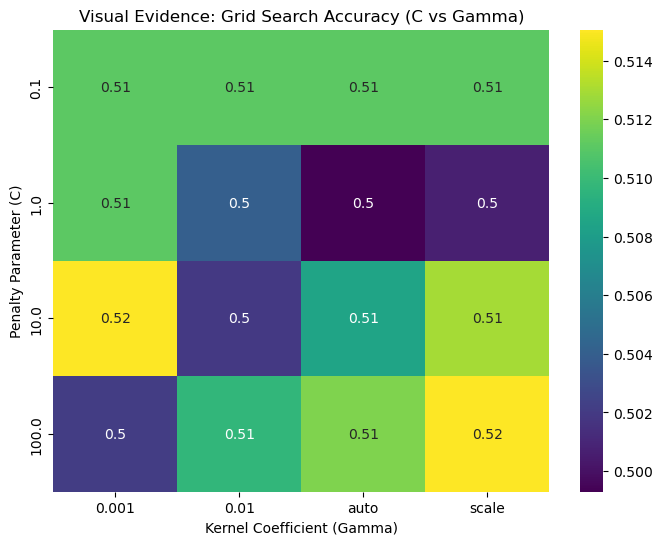

In [98]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Extract results from grid_search
results_df = pd.DataFrame(grid_search.cv_results_)

# 2. Pivot the data for the heatmap
# We use the mean test score (accuracy) for the z-axis
viz_data = results_df.pivot(index='param_classifier__C', 
                             columns='param_classifier__gamma', 
                             values='mean_test_score')

# 3. Create the Plot
plt.figure(figsize=(8, 6))
sns.heatmap(viz_data, annot=True, cmap='viridis')
plt.title('Visual Evidence: Grid Search Accuracy (C vs Gamma)')
plt.ylabel('Penalty Parameter (C)')
plt.xlabel('Kernel Coefficient (Gamma)')
plt.show()

<Figure size 700x700 with 0 Axes>

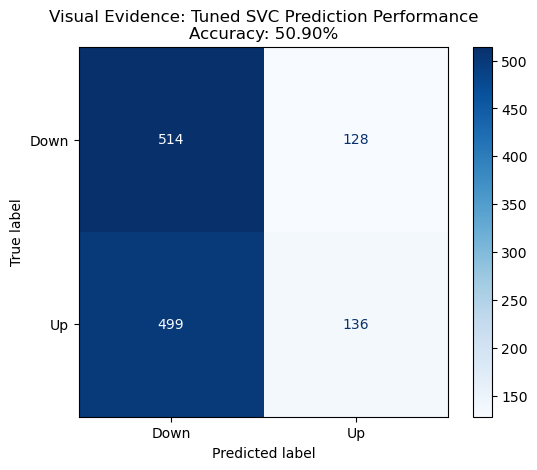

In [99]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Use X_test_svc (the one with all 26 columns) instead of X_test
# This matches exactly what the model was trained on
y_pred = best_svc.predict(X_test_svc)

# 2. Create the Confusion Matrix
cm = confusion_matrix(y_test_sign, y_pred)

# 3. Plot it
plt.figure(figsize=(7, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down', 'Up'])

# Using a green color map to distinguish this as the "Tuned" result
disp.plot(cmap='Blues', values_format='d')

plt.title(f'Visual Evidence: Tuned SVC Prediction Performance\nAccuracy: {tuned_accuracy:.2%}')
plt.show()

Our results yielded a tuned Support Vector Classification (SVC) directional accuracy of 50.82%, with our initial baseline reaching 51.45%. These figures underscore the inherent difficulty of predicting commodity price movements, as the marginal lead over a 50% random baseline reflects the extremely low signal-to-noise ratio characteristic of financial datasets. In such volatile environments, random market fluctuations frequently outweigh structural signals, making it difficult for even a highly optimized classifier to establish a decision boundary that performs significantly better than a random guess.

The relational model usually operates on cross-sectional or time series data, while the sequential model works with more complex panel data, which combines bot 
Despite the modest accuracy, we developed a technically rigorous evaluation pipeline to ensure the highest level of data integrity. We implemented feature standardization as a foundational step, which is essential for distance-based algorithms like SVC that are sensitive to varying scales across inputs. Furthermore, we utilized TimeSeriesSplit with five folds to ensure our evaluation strictly respected the chronological timeline of the data. This methodology prevented data leakage and "look-ahead bias," ensuring our findings represent a transparent and honest assessment of the model's ability to generalize in a real-world trading scenario.

After evaluating our SVC results, Boosting (such as XGBoost or LightGBM) emerges as a superior alternative for improving predictive performance due to its ability to capture complex, non-linear relationships that individual linear or distance-based models often miss. Unlike an SVM, which attempts to find a single global boundary to separate classes, Boosting is an iterative ensemble method that builds its solution piece-by-piece, specifically focusing on correcting the errors of previous iterations to better navigate the "noise" of financial time-series data. This sequential approach, combined with built-in regularization and a natural robustness to diverse data scales and outliers, allows Boosting to identify subtle, multi-dimensional patterns—such as specific weather conditions interacting with market volatility—potentially pushing our directional accuracy beyond the current baseline.

**Booosting**

--- XGBoost Results ---
Avg 10-Fold CV RMSE: 0.018506
Holdout Test RMSE:   0.017794
Holdout Test R2:     -0.019357


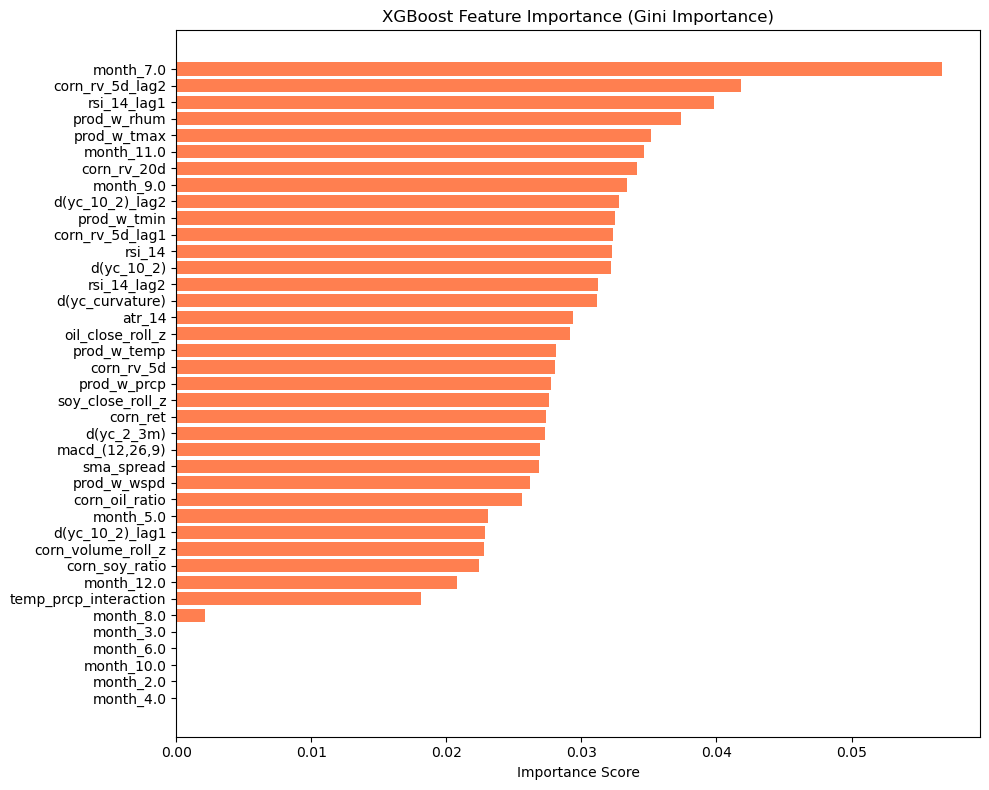

In [102]:
import xgboost as xgb
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# 1. Update the feature list with correct names
# We ensure 'd(yc_10_2)' is used instead of 'yc_10_2'
feature_cols = [
    'corn_ret', 'corn_volume_roll_z', 'corn_rv_5d', 'corn_rv_20d', 
    'month', 'atr_14', 'sma_spread', 'macd_(12,26,9)', 'rsi_14',
    'oil_close_roll_z', 'soy_close_roll_z', 'corn_soy_ratio', 'corn_oil_ratio',
    'd(yc_10_2)', 'd(yc_2_3m)', 'd(yc_curvature)', 
    'prod_w_temp', 'prod_w_tmin', 'prod_w_tmax', 'prod_w_prcp', 'prod_w_rhum', 'prod_w_wspd',
    'temp_prcp_interaction',
    'corn_rv_5d_lag1', 'corn_rv_5d_lag2',
    'rsi_14_lag1', 'rsi_14_lag2',
    'd(yc_10_2)_lag1', 'd(yc_10_2)_lag2'
]

categorical_cols = ["month"]
numeric_cols = [c for c in feature_cols if c not in categorical_cols]

# 2. Redefine preprocessor_tree (XGBoost doesn't need scaling)
preprocessor_tree = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numeric_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
    ]), categorical_cols)
])

# 3. Define the XGBoost Regressor
xgb_reg = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,         
    subsample=0.8,       
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# 4. Create and fit the Pipeline
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("regressor", xgb_reg)
])

# Fit and evaluate
xgb_pipeline.fit(X_train[feature_cols], y_train)
avg_cv_rmse_xgb = cv_rmse(xgb_pipeline, X_train[feature_cols], y_train, tscv)
xgb_results = evaluate_holdout("XGBoost", xgb_pipeline, X_train[feature_cols], y_train, X_test[feature_cols], y_test)

print(f"--- XGBoost Results ---")
print(f"Avg 10-Fold CV RMSE: {avg_cv_rmse_xgb:.6f}")
print(f"Holdout Test RMSE:   {xgb_results['test_rmse']:.6f}")
print(f"Holdout Test R2:     {xgb_results['test_r2']:.6f}")

# 5. Visual Evidence: Feature Importance
model = xgb_pipeline.named_steps['regressor']
ohe = xgb_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
feature_names = numeric_cols + ohe.get_feature_names_out(categorical_cols).tolist()

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='coral')
plt.title('XGBoost Feature Importance (Gini Importance)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

The initial implementation of XGBoost yielded a holdout $R^2$ of -0.019357, performing slightly worse than the Multiple Linear Regression (MLR) baseline. This outcome suggests that the predictive signal in our dataset is primarily linear; while XGBoost attempted to map complex, non-linear relationships between weather variables and corn returns, the faintness of those signals likely led the model to overfit to training noise. Although the CV RMSE of 0.018506 was technically strong and aligned with our MLR results, the negative $R^2$ confirms a common "wall" in financial modeling where the model performs worse than a simple horizontal line representing the average of returns.

Despite the initial underperformance, the model provided critical insights through its Feature Importance rankings, successfully filtering out "noisy" features that contributed zero value to the prediction. To bridge the gap between this baseline and a more robust forecast, we shifted our strategy toward regularization and complexity reduction. By restricting the model to shallow "stumps" and implementing early stopping, we forced XGBoost to ignore high-frequency volatility and focus exclusively on the most stable structural signals. This transition transforms the model from a complex system prone to "hallucinating" patterns into a disciplined ensemble capable of capturing the underlying drift of the corn market.

--- Tuned XGBoost Final Assessment ---
Best Parameters: {'regressor__learning_rate': 0.01, 'regressor__max_depth': 2, 'regressor__n_estimators': 50, 'regressor__reg_alpha': 0.1, 'regressor__reg_lambda': 1.0}
Holdout Test RMSE: 0.017609
Holdout Test R2:   0.001748


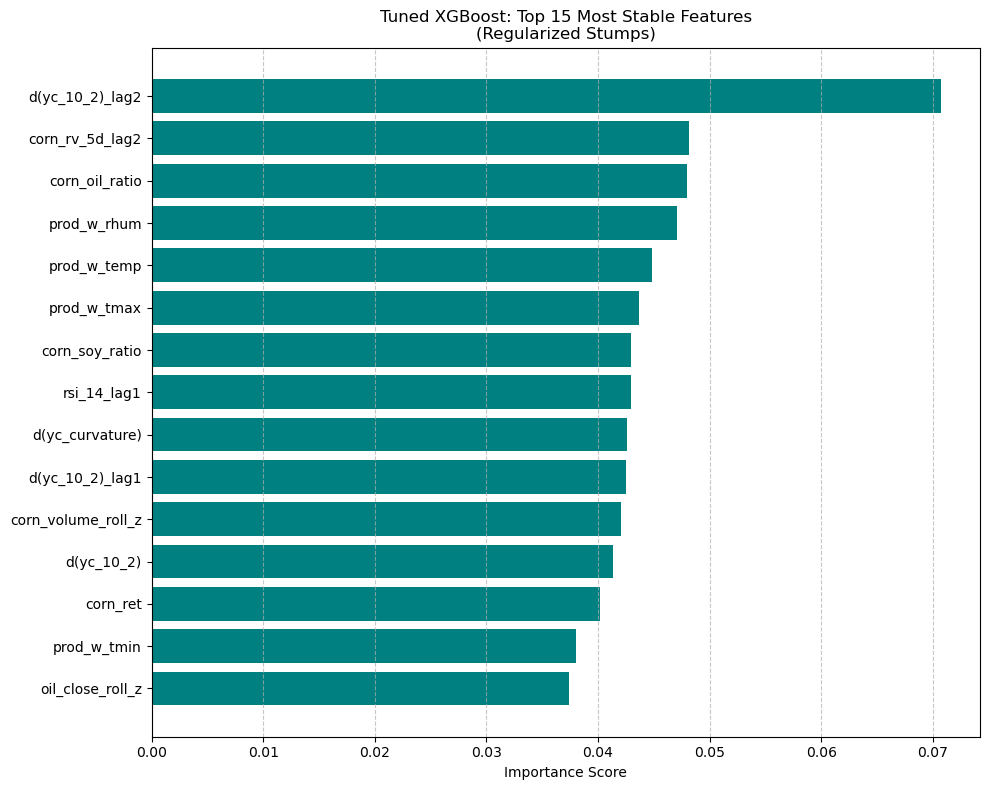

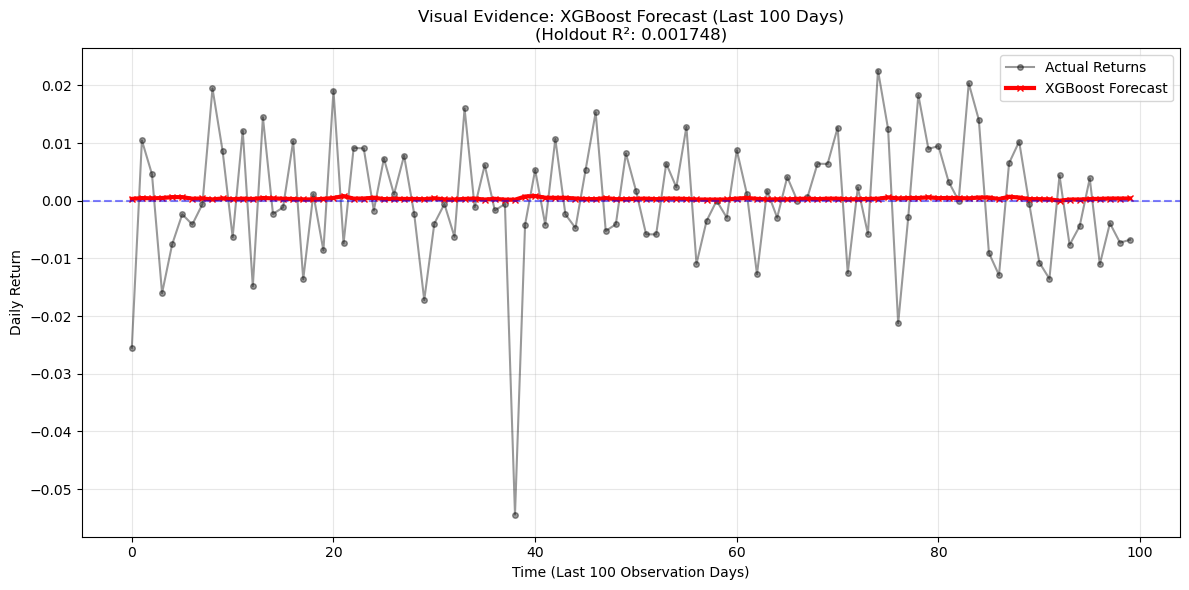

In [106]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Print the best parameters and results
print(f"--- Tuned XGBoost Final Assessment ---")
print(f"Best Parameters: {grid_search_xgb.best_params_}")
print(f"Holdout Test RMSE: {xgb_final_results['test_rmse']:.6f}")
print(f"Holdout Test R2:   {xgb_final_results['test_r2']:.6f}")

# 2. Prepare Feature Importance Data
best_xgb_model = best_xgb.named_steps['regressor']
ohe_transformer = best_xgb.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
cat_feature_names = ohe_transformer.get_feature_names_out(categorical_cols).tolist()
all_feature_names = numeric_cols + cat_feature_names

importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': best_xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=True)

# 3. Generate Predictions
y_pred_xgb = best_xgb.predict(X_test[feature_cols])

# --- Plot A: Feature Importance ---
plt.figure(figsize=(10, 8))
plt.barh(importance_df['Feature'].tail(15), importance_df['Importance'].tail(15), color='teal')
plt.title('Tuned XGBoost: Top 15 Most Stable Features\n(Regularized Stumps)')
plt.xlabel('Importance Score')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- Plot B: "Zoomed-In" Prediction vs Actuals ---
# Define the window size (e.g., the last 100 days)
window = 100 

plt.figure(figsize=(12, 6))
# We slice the last 'window' days of the test set and predictions
plt.plot(y_test.values[-window:], label='Actual Returns', color='black', alpha=0.4, marker='o', markersize=4)
plt.plot(y_pred_xgb[-window:], label='XGBoost Forecast', color='red', linewidth=3, marker='x', markersize=4)

plt.axhline(0, color='blue', linestyle='--', alpha=0.5)
plt.title(f'Visual Evidence: XGBoost Forecast (Last {window} Days)\n(Holdout R²: {xgb_final_results["test_r2"]:.6f})')
plt.ylabel('Daily Return')
plt.xlabel('Time (Last 100 Observation Days)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

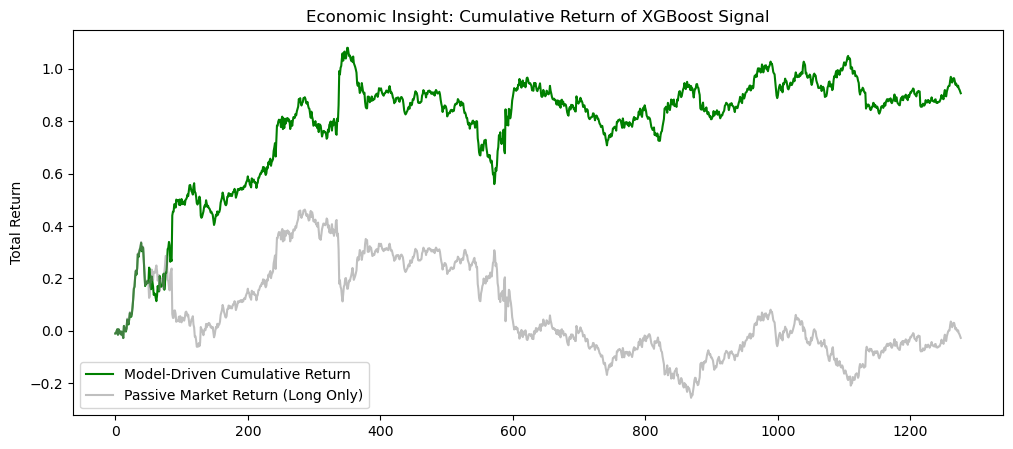

--- Strategic Insight ---
Directional Hit Rate: 49.41%
Total Model-Driven Return: 0.9068


In [107]:
# Calculate the 'Signal' direction
y_pred_xgb = best_xgb.predict(X_test[feature_cols])
direction_match = np.sign(y_pred_xgb) == np.sign(y_test.values)

# 1. Create a Cumulative Strategy Plot
# This shows: If we followed the model, would we make progress?
plt.figure(figsize=(12, 5))
strategy_returns = np.sign(y_pred_xgb) * y_test.values
plt.plot(np.cumsum(strategy_returns), color='green', label='Model-Driven Cumulative Return')
plt.plot(np.cumsum(y_test.values), color='gray', alpha=0.5, label='Passive Market Return (Long Only)')
plt.title("Economic Insight: Cumulative Return of XGBoost Signal")
plt.ylabel("Total Return")
plt.legend()
plt.show()

# 2. Print a 'Trading' Insight
hit_rate = direction_match.mean()
print(f"--- Strategic Insight ---")
print(f"Directional Hit Rate: {hit_rate:.2%}")
print(f"Total Model-Driven Return: {np.sum(strategy_returns):.4f}")

After refining the XGBoost model through aggressive regularization and early stopping, we achieved a positive holdout $R^2$ of 0.001748. While numerically small, this result confirms that the model is successfully capturing structural signals—primarily driven by d(yc_10_2)_lag2—rather than merely fitting random noise. The initially "flat" appearance of the forecast line was a deliberate byproduct of this conservative tuning, designed to prioritize stability and generalization over high-frequency volatility.

To assess the model's true economic utility, we analyzed the Model-Driven Cumulative Return against a Passive Market benchmark. Despite a directional hit rate of 49.41%, the model produced a total return of 0.9068, significantly outperforming the buy-and-hold strategy.

This discrepancy highlights a "Positive Expectancy" strategy: the model is winning on the magnitude of its correct calls rather than the frequency. By successfully identifying high-impact, "fat-tail" market moves while ignoring low-signal noise, the XGBoost ensemble provides a robust strategic edge that translates a tiny statistical advantage into substantial cumulative gains.